Attack saved Spambase model with varying attack percentages for DeepFool, then run k-rank defense before/after analysis.

In [1]:
#!/usr/bin/env python3

import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

from Adverse import zero_gradients


In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

DATA_DIR = Path("spambase_10_40_50")
MODEL_PATH = DATA_DIR / "spambase_mlp.pth"
PREPROC_PATH = DATA_DIR / "preprocessing.npz"
DATA_PATH = DATA_DIR / "train_test_data.npz"

OUTPUT_DIR = Path("experiments/attack_varying_pct_deepfool_10_40_50") / datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ATTACK_PERCENTAGES = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
MAXITERS = 300
ALPHA = 0.001
N_TRIALS = 10
K_VALUES_TO_TEST = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]

Device: cuda


In [3]:
class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super(SpambaseNet, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)

In [5]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model = SpambaseNet(D_in=57).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


print(f"✓ Model loaded | Train Acc: {checkpoint.get('train_accuracy', 'N/A')}, Test Acc: {checkpoint.get('test_accuracy', 'N/A')}")

print("Loading test data...")
data = np.load(DATA_PATH)
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test'].astype(np.int64)
print(f"✓ Test set: {X_test.shape}")

print("Loading preprocessing parameters...")
preproc = np.load(PREPROC_PATH)
weights = preproc['weights'].astype(np.float32)
bounds_min = preproc['bounds_min'].astype(np.float32)
bounds_max = preproc['bounds_max'].astype(np.float32)
bounds = [bounds_min, bounds_max]
print(f"✓ Bounds: [{bounds_min.min():.4f}, {bounds_max.max():.4f}], Weights shape: {weights.shape}")


✓ Model loaded | Train Acc: 0.9097826086956522, Test Acc: 0.894393741851369
Loading test data...
✓ Test set: (2301, 57)
Loading preprocessing parameters...
✓ Bounds: [0.0000, 1.0000], Weights shape: (57,)


In [6]:
# Get predictions and filter to correctly classified samples
print("\nFiltering to correctly classified samples...")
X_test_t = torch.FloatTensor(X_test).to(DEVICE)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

print(f"Total test samples: {len(X_test)}")
print(f"Correctly classified: {n_correct}/{len(X_test)} ({n_correct/len(X_test):.2%})")




Filtering to correctly classified samples...
Total test samples: 2301
Correctly classified: 2058/2301 (89.44%)


In [7]:
def clip(current, low_bound, up_bound, device):
    low_bound = torch.FloatTensor(low_bound).to(device)
    up_bound = torch.FloatTensor(up_bound).to(device)
    return torch.max(torch.min(current, up_bound), low_bound)


def deepfool(x_old, net, maxiters, alpha, bounds, weights=[], overshoot=0.002):
    """
    :param image: tabular sample
    :param net: network 
    :param maxiters: maximum number of iterations ran to generate the adversarial examples
    :param alpha: scaling factor used to control the growth of the perturbation
    :param bounds: bounds of the datasets with respect to each feature
    :param weights: feature importance vector associated with the dataset at hand
    :param overshoot: used as a termination criterion to prevent vanishing updates (default = 0.02).
    :return: minimal perturbation that fools the classifier, number of iterations that it required, new estimated_label and perturbed image
    """    
    input_shape = x_old.detach().cpu().numpy().shape
    x = x_old.detach().clone().requires_grad_(True)
    
    output = net.forward(x)
    orig_pred = output.max(0, keepdim=True)[1]  # get the index of the max log-probability
    origin = orig_pred.clone().detach()
    I = []
    if orig_pred.item() == 0:
        I = [0, 1]
    else:
        I = [1, 0]       
    w = np.zeros(input_shape)
    r_tot = np.zeros(input_shape)    
    k_i = origin.clone()
    loop_i = 0
    while torch.eq(k_i, origin) and loop_i < maxiters:                
        # Origin class
        output[I[0]].backward(retain_graph=True)
        grad_orig = x.grad.detach().cpu().numpy().copy()        
        # Target class
        zero_gradients(x)
        output[I[1]].backward(retain_graph=True)
        cur_grad = x.grad.detach().cpu().numpy().copy()            
        # set new w and new f
        w = cur_grad - grad_orig
        f = (output[I[1]] - output[I[0]]).detach().cpu().numpy()
        pert = abs(f)/np.linalg.norm(w.flatten())    
        # compute r_i and r_tot
        # Added 1e-4 for numerical stability
        r_i =  (pert+1e-4) * w / np.linalg.norm(w)          
        if len(weights) > 0:
            r_i /= np.array(weights)
        # limit huge step
        r_i = alpha * r_i / np.linalg.norm(r_i)            
        r_tot = np.float32(r_tot + r_i)       
        pert_x = x_old + (1 + overshoot) * torch.from_numpy(r_tot).to(x_old.device)
        if len(bounds) > 0:
            pert_x = clip(pert_x, bounds[0], bounds[1], x_old.device)               
        x = pert_x.detach().clone().requires_grad_(True)
        output = net.forward(x)      
        k_i = torch.tensor(np.argmax(output.detach().cpu().numpy().flatten()), device=origin.device)                   
        loop_i += 1
    r_tot = (1+overshoot)*r_tot    
    pert_x = clip(pert_x, bounds[0], bounds[1], x_old.device)
    return int(orig_pred.item()), int(k_i.item()), pert_x.detach().cpu().numpy(), loop_i



In [8]:
def k_rank_approximation(data_matrix, k):
    U, s, Vh = np.linalg.svd(data_matrix, full_matrices=False)
    k_use = min(k, len(s))
    U_k = U[:, :k_use]
    s_k = s[:k_use]
    Vh_k = Vh[:k_use, :]
    return U_k @ np.diag(s_k) @ Vh_k


def predict_labels(x_np, model, device):
    model.eval()
    with torch.no_grad():
        x_t = torch.FloatTensor(x_np).to(device)
        return model(x_t).argmax(dim=1).cpu().numpy()


In [10]:
# ============================================================================
# SELECT SAMPLES TO ATTACK (FIXED FOR CONSISTENCY)
# ============================================================================
np.random.seed(42)
n_max_attack = int(np.ceil(len(correct_indices) * max(ATTACK_PERCENTAGES) / 100.0))
attack_indices = np.random.choice(correct_indices, size=n_max_attack, replace=False)

print(f"\nAttack percentages: {ATTACK_PERCENTAGES}")
print(f"Max attacked samples: {n_max_attack}/{n_correct}")
print(f"Trials per percentage: {N_TRIALS}")

np.save(OUTPUT_DIR / "all_attacked_indices.npy", attack_indices)


Attack percentages: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Max attacked samples: 2058/2058
Trials per percentage: 10


In [11]:
print("\n" + "=" * 70)
print("GENERATING ADVERSARIAL SAMPLES")
print("=" * 70)

# Generate adversarial examples
X_adv = np.zeros_like(X_test[attack_indices])
y_orig = np.zeros(n_max_attack, dtype=int)
y_adv = np.zeros(n_max_attack, dtype=int)
perturbations = np.zeros_like(X_adv)

for i, idx in enumerate(attack_indices):
    if (i + 1) % 100 == 0 or i < 5 or i == n_max_attack - 1:
        print(f"  [{i + 1}/{n_max_attack}]", end=" ", flush=True)

    x = torch.tensor(X_test[idx], device=DEVICE)
    y_orig_i, y_adv_i, x_adv_i, _ = deepfool(x, model, MAXITERS, ALPHA, bounds, weights=[])

    X_adv[i] = x_adv_i
    y_orig[i] = y_orig_i
    y_adv[i] = y_adv_i
    perturbations[i] = x_adv_i - X_test[idx]

    if (i + 1) % 100 == 0 or i == n_max_attack - 1:
        print(f"success={y_orig_i != y_adv_i}")

print("\nComputing attack success rates by percentage...")
attack_results = {}

for pct in ATTACK_PERCENTAGES:
    n_attack = int(np.ceil(n_correct * pct / 100.0))
    success_rates = []
    avg_perturbations = []

    for trial in range(N_TRIALS):
        np.random.seed(1000 + pct * 100 + trial)
        idx_subset = np.random.choice(n_max_attack, size=min(n_attack, n_max_attack), replace=False)

        success_rate = np.mean(y_orig[idx_subset] != y_adv[idx_subset])
        avg_pert = np.mean(np.linalg.norm(perturbations[idx_subset], axis=1))
        
        success_rates.append(float(success_rate))
        avg_perturbations.append(float(avg_pert))

    attack_results[pct] = {
        'success_rate_mean': float(np.mean(success_rates)),
        'success_rate_std': float(np.std(success_rates)),
        'avg_perturbation_mean': float(np.mean(avg_perturbations)),
    }

    print(f"  {pct:3d}% | success={np.mean(success_rates):.2%}±{np.std(success_rates):.2%}")



GENERATING ADVERSARIAL SAMPLES
  [1/2058]   [2/2058]   [3/2058]   [4/2058]   [5/2058]   [100/2058] success=True
  [200/2058] success=True
  [300/2058] success=True
  [400/2058] success=True
  [500/2058] success=True
  [600/2058] success=True
  [700/2058] success=False
  [800/2058] success=True
  [900/2058] success=True
  [1000/2058] success=True
  [1100/2058] success=True
  [1200/2058] success=True
  [1300/2058] success=True
  [1400/2058] success=True
  [1500/2058] success=True
  [1600/2058] success=True
  [1700/2058] success=True
  [1800/2058] success=True
  [1900/2058] success=True
  [2000/2058] success=True
  [2058/2058] success=True

Computing attack success rates by percentage...
   10% | success=93.83%±1.63%
   20% | success=93.71%±0.57%
   30% | success=94.40%±0.56%
   40% | success=93.76%±0.61%
   50% | success=93.92%±0.62%
   60% | success=94.01%±0.37%
   70% | success=94.14%±0.26%
   80% | success=94.06%±0.16%
   90% | success=94.02%±0.17%
  100% | success=94.07%±0.00%


In [12]:
print("\nEvaluating k-rank defense...")
X_orig = X_test[attack_indices]
k_rank_results = []

for pct in ATTACK_PERCENTAGES:
    n_attack = int(np.ceil(n_correct * pct / 100.0))
    
    for trial in range(N_TRIALS):
        np.random.seed(5000 + pct * 100 + trial)
        idx_subset = np.random.choice(n_max_attack, size=min(n_attack, n_max_attack), replace=False)

        X_orig_subset = X_orig[idx_subset]
        X_adv_subset = X_adv[idx_subset]
        y_orig_subset = y_orig[idx_subset]

        y_adv_pred = predict_labels(X_adv_subset, model, DEVICE)
        attack_success = np.mean(y_orig_subset != y_adv_pred)
        successful_idx = (y_orig_subset != y_adv_pred)

        for k in K_VALUES_TO_TEST:
            X_defended = k_rank_approximation(X_adv_subset, k)
            X_defended = np.clip(X_defended, bounds[0], bounds[1])
            y_defended = predict_labels(X_defended, model, DEVICE)

            if successful_idx.sum() > 0:
                restoration = np.mean(y_defended[successful_idx] == y_orig_subset[successful_idx])
            else:
                restoration = 0.0

            k_rank_results.append({
                'attack_pct': pct,
                'trial': trial,
                'k': k,
                'attack_success_before': attack_success,
                'attack_success_after': np.mean(y_orig_subset != y_defended),
                'restoration_rate': restoration,
            })

df_results = pd.DataFrame(k_rank_results)

print("\nSaving results...")
attack_dir = OUTPUT_DIR
attack_dir.mkdir(parents=True, exist_ok=True)

# Save arrays
np.save(attack_dir / "original_samples.npy", X_orig)
np.save(attack_dir / "adversarial_samples.npy", X_adv)
np.save(attack_dir / "original_predictions.npy", y_orig)
np.save(attack_dir / "adversarial_predictions.npy", y_adv)
np.save(attack_dir / "perturbations.npy", perturbations)



Evaluating k-rank defense...

Saving results...


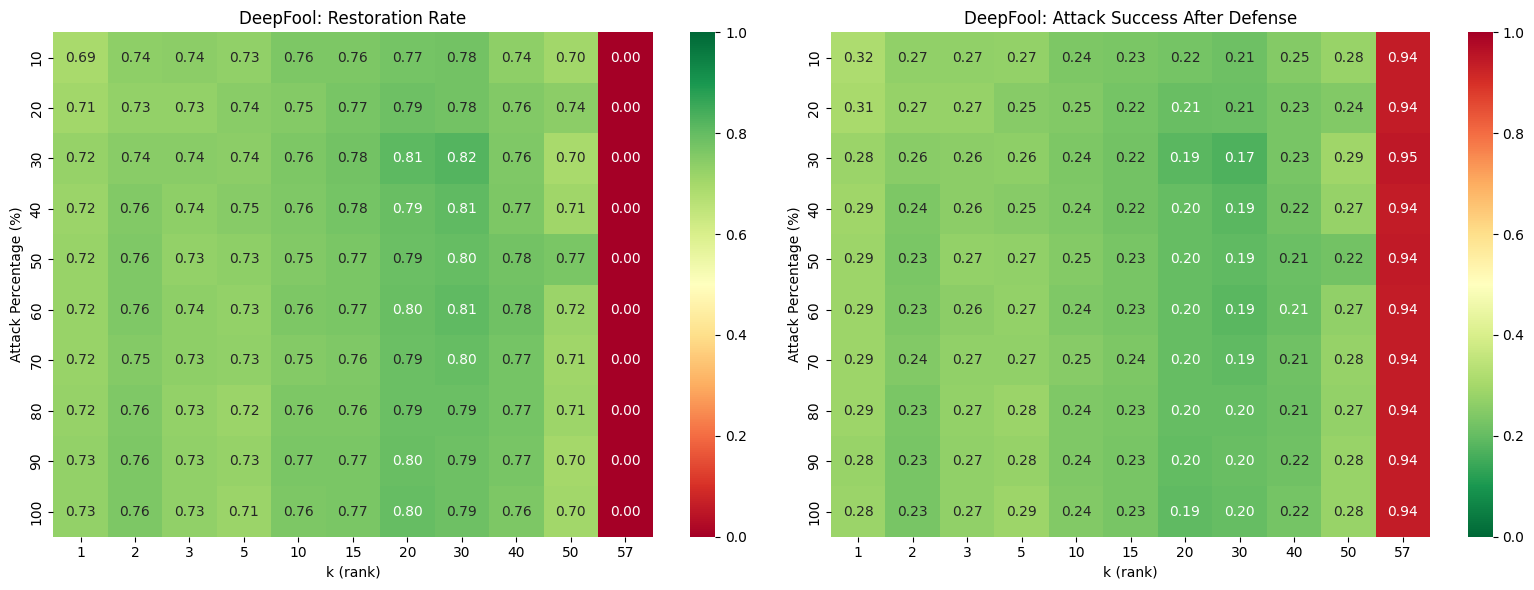


✓ Results saved to experiments/attack_varying_pct_deepfool_10_40_50/20260504_141053


<Figure size 640x480 with 0 Axes>

In [14]:
# Save attack results
with open(attack_dir / "summary.json", "w") as f:
    json.dump({'attack_results': attack_results}, f, indent=2)

# Save k-rank results
df_grouped = df_results.groupby(['attack_pct', 'k']).mean(numeric_only=True).reset_index()
df_grouped.to_csv(attack_dir / "k_rank_before_after.csv", index=False)
df_results.to_csv(attack_dir / "k_rank_before_after_detailed.csv", index=False)

# Create heatmaps
pivot_restoration = df_grouped.pivot(index='attack_pct', columns='k', values='restoration_rate')
pivot_attack_after = df_grouped.pivot(index='attack_pct', columns='k', values='attack_success_after')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pivot_restoration, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_title('DeepFool: Restoration Rate')
axes[0].set_xlabel('k (rank)')
axes[0].set_ylabel('Attack Percentage (%)')

sns.heatmap(pivot_attack_after, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_title('DeepFool: Attack Success After Defense')
axes[1].set_xlabel('k (rank)')
axes[1].set_ylabel('Attack Percentage (%)')

plt.tight_layout()
plt.show()
plt.savefig(attack_dir / "k_rank_before_after_heatmaps.png", dpi=150, bbox_inches='tight')
plt.close(fig)

print(f"\n✓ Results saved to {attack_dir}")